In [ ]:
!pip install -U transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 38.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'mnli_m',
                'quantization': '4bit',
                'training_mode': 'few shot 15 examples',
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_examples.pt


In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'mnli_mm',
                'quantization': '4bit',
                'training_mode': 'few shot 1 m examples neutral',
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_m_examples_neutral.pt


In [ ]:
# Login to HuggingFace
utils.hf_login("HF_TOKEN")

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    quantization_config=quantization_config,
    attn_implementation="eager"
    )

# Add padding token to the tokenizer and change padding side
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [ ]:
# Get 15 indices using train_test_split with stratify
# files.upload()
mnli_m_val = pd.read_csv('mnli_mm_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})
test_idx, train_idx = train_test_split(mnli_m_val.index, test_size=15, stratify=mnli_m_val['label'], random_state=42)

np.save('mnli_mm_few_shot_example_idx.npy', train_idx)

Saving mnli_mm_val.csv to mnli_mm_val.csv


In [ ]:
# Upload file with the locked indices
files.upload()

Saving mnli_mm_few_shot_example_idx.npy to mnli_mm_few_shot_example_idx.npy


{'mnli_mm_few_shot_example_idx.npy': b"\x93NUMPY\x01\x00v\x00{'descr': '<i8', 'fortran_order': False, 'shape': (15,), }                                                           \n6%\x00\x00\x00\x00\x00\x00\xbb\x0c\x00\x00\x00\x00\x00\x00\x8f%\x00\x00\x00\x00\x00\x00(\x0f\x00\x00\x00\x00\x00\x00\xb3\x1c\x00\x00\x00\x00\x00\x00l\x07\x00\x00\x00\x00\x00\x00\xed\x1c\x00\x00\x00\x00\x00\x00-\r\x00\x00\x00\x00\x00\x00*\x1b\x00\x00\x00\x00\x00\x00V%\x00\x00\x00\x00\x00\x00\x1a\n\x00\x00\x00\x00\x00\x00\xce\x0c\x00\x00\x00\x00\x00\x00\x19\x00\x00\x00\x00\x00\x00\x00\x9e \x00\x00\x00\x00\x00\x003\x02\x00\x00\x00\x00\x00\x00"}

In [ ]:
# Lock 15 examples to be used for few shot
# files.upload()
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_m_few_shot_example_idx.npy')

k = 15 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[:k]]
mnli_m_val_few_shot = mnli_m_val.drop(mnli_m_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Premise: yeah no i don't know if there's any any series that i pay attention to i try to watch Cheers once in a while
Hypothesis: I watch Cheers everynow and then, but I don't watch many series.
Answer: entailment 

Example 2
Premise: my goodness it's hard to believe i didn't think there was anybody in the country who hadn't seen that one
Hypothesis: I thought everyone in the US had already seen that movie. 
Answer: neutral 

Example 3
Premise: As Ben Yagoda writes in the New York Times Book Review , somewhere along the way, Kidder must have decided not to write a book about Tommy O'Connor.
Hypothesis: A book was not written about Tommy O'Connor.
Answer: entailment 

Example 4
Premise: uh-huh well maybe well i've enjoyed talking to you okay bye-bye
Hypothesis: I liked talking to you.
Answer: entailment 

Example 5
Premise: Even if auditors do not follow such other standards and methodologies, they may still serve as a useful source of guidance to auditors in planning their wo

In [ ]:
# Lock 1 opposite examples to be used for few shot
# files.upload()
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_m_few_shot_example_idx_fixed.npy')

k = 2 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[k]]
mnli_m_val_few_shot = mnli_m_val.drop(mnli_m_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
prompt_examples += f"Example 1\nPremise: {demo_examples['premise']}\nHypothesis: {demo_examples['hypothesis']}\nAnswer: {demo_examples['label']} \n\n"

print(prompt_examples)

Example 1
Premise: In addition, Saracens invaded the Provencal coast from North Africa, and Magyar armies attacked Lor?­raine and Bur?­gun?­dy.
Hypothesis: The Magyar armies did not attack anyone.
Answer: contradiction 




In [ ]:
demo_examples

,promptID,pairID,premise,premise_binary_parse,premise_parse,hypothesis,hypothesis_binary_parse,hypothesis_parse,genre,label
4648,89209,89209e,yeah no i don't know if there's any any series...,( yeah ( ( no i ) ( ( do n't ) ( know ( if ( t...,(ROOT (S (VP (VB yeah) (SBAR (S (NP (DT no) (F...,"I watch Cheers everynow and then, but I don't ...",( ( ( ( ( I ( watch ( ( ( Cheers everynow ) an...,(ROOT (S (S (NP (PRP I)) (VP (VBP watch) (NP (...,telephone,entailment
3170,53499,53499n,my goodness it's hard to believe i didn't thin...,( ( ( my goodness ) ( it ( 's ( hard ( to ( be...,(ROOT (S (NP (NP (PRP$ my) (NN goodness)) (SBA...,I thought everyone in the US had already seen ...,( I ( ( thought ( ( everyone ( in ( the US ) )...,(ROOT (S (NP (PRP I)) (VP (VBD thought) (SBAR ...,telephone,neutral
6993,96516,96516e,As Ben Yagoda writes in the New York Times Boo...,( ( As ( ( Ben Yagoda ) ( writes ( ( ( ( in ( ...,(ROOT (S (SBAR (IN As) (S (NP (NNP Ben) (NNP Y...,A book was not written about Tommy O'Connor.,( ( A book ) ( ( ( was not ) ( written ( about...,(ROOT (S (NP (DT A) (NN book)) (VP (VBD was) (...,slate,entailment
7568,141591,141591e,uh-huh well maybe well i've enjoyed talking to...,( ( uh-huh ( ( well ( maybe well ) ) i ) ) ( '...,(ROOT (S (NP (NP (NN uh-huh)) (ADJP (ADVP (RB ...,I liked talking to you.,( I ( ( liked ( talking ( to you ) ) ) . ) ),(ROOT (S (NP (PRP I)) (VP (VBD liked) (S (VP (...,telephone,entailment
6558,84055,84055n,Even if auditors do not follow such other stan...,( ( Even ( if ( auditors ( ( do not ) ( follow...,(ROOT (S (SBAR (RB Even) (IN if) (S (NP (NNS a...,GAGAS requires strict compliance for auditors ...,( GAGAS ( ( ( ( requires ( strict compliance )...,(ROOT (S (NP (NNS GAGAS)) (VP (VBZ requires) (...,government,neutral
3183,101242,101242c,"In addition, Saracens invaded the Provencal co...","( ( In addition ) ( , ( ( ( ( ( Saracens ( ( i...","(ROOT (S (PP (IN In) (NP (NN addition))) (, ,)...",The Magyar armies did not attack anyone.,( ( The ( Magyar armies ) ) ( ( ( did not ) ( ...,(ROOT (S (NP (DT The) (NNP Magyar) (NNS armies...,travel,contradiction
9697,55360,55360c,The search for an AIDS vaccine currently needs...,( ( ( The search ) ( for ( an ( AIDS vaccine )...,(ROOT (S (NP (NP (DT The) (NN search)) (PP (IN...,There has been no past or present search for a...,( There ( ( has ( been ( ( no ( ( ( past or ) ...,(ROOT (S (NP (EX There)) (VP (VBZ has) (VP (VB...,slate,contradiction
7949,133296,133296c,The family.,( The ( family . ) ),(ROOT (NP (DT The) (NN family) (. .))),The couple.,( The ( couple . ) ),(ROOT (NP (DT The) (NN couple) (. .))),fiction,neutral
3291,140919,140919c,"I see, said Tuppence thoughtfully.","( ( I see ) ( , ( ( said ( Tuppence thoughtful...","(ROOT (SINV (S (NP (PRP I)) (VP (VBP see))) (,...","""I can't comprehend it,"" said Tuppence fitfully.",( `` ( ( I ( ( ca n't ) ( comprehend it ) ) ) ...,(ROOT (SINV (`` ``) (S (NP (PRP I)) (VP (MD ca...,fiction,contradiction
4849,99215,99215e,"Clearly, the press has done a lousy job with i...","( Clearly ( , ( ( the press ) ( ( has ( ( ( do...","(ROOT (S (ADVP (RB Clearly)) (, ,) (NP (DT the...",The press has focused on various topics that m...,( ( The press ) ( ( has ( ( focused ( on ( var...,(ROOT (S (NP (DT The) (NN press)) (VP (VBZ has...,slate,entailment


In [ ]:
mnli_m_val_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 0 to 9814
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   promptID                 9800 non-null   int64 
 1   pairID                   9800 non-null   object
 2   premise                  9800 non-null   object
 3   premise_binary_parse     9800 non-null   object
 4   premise_parse            9800 non-null   object
 5   hypothesis               9800 non-null   object
 6   hypothesis_binary_parse  9800 non-null   object
 7   hypothesis_parse         9800 non-null   object
 8   genre                    9800 non-null   object
 9   label                    9800 non-null   object
dtypes: int64(1), object(9)
memory usage: 842.2+ KB


In [ ]:
mnli_m_val_few_shot.label.unique()

array(['neutral', 'contradiction', 'entailment'], dtype=object)

In [ ]:
mnli_m_val_few_shot.head()

,promptID,pairID,premise,premise_binary_parse,premise_parse,hypothesis,hypothesis_binary_parse,hypothesis_parse,genre,label
0,63735,63735n,The new rights are nice enough,( ( The ( new rights ) ) ( are ( nice enough )...,(ROOT (S (NP (DT The) (JJ new) (NNS rights)) (...,Everyone really likes the newest benefits,( Everyone ( really ( likes ( the ( newest ben...,(ROOT (S (NP (NN Everyone)) (VP (ADVP (RB real...,slate,neutral
1,91383,91383c,This site includes a list of all award winners...,( ( This site ) ( ( includes ( ( ( ( a list ) ...,(ROOT (S (NP (DT This) (NN site)) (VP (VBZ inc...,The Government Executive articles housed on th...,( ( ( The ( Government ( Executive articles ) ...,(ROOT (S (NP (NP (DT The) (NNP Government) (NN...,government,contradiction
2,755,755e,uh i don't know i i have mixed emotions about ...,( ( ( ( uh ( i ( ( do n't ) ( know ( ( i i ) (...,(ROOT (SINV (S (S (INTJ (UH uh)) (NP (FW i)) (...,"I like him for the most part, but would still ...",( I ( ( ( ( ( ( like him ) ( for ( the ( most ...,(ROOT (S (NP (PRP I)) (VP (VP (VBP like) (NP (...,telephone,entailment
3,78013,78013c,yeah i i think my favorite restaurant is alway...,( yeah ( ( i i ) ( think ( ( my ( favorite res...,(ROOT (S (VP (VB yeah) (NP (NP (FW i) (FW i)) ...,My favorite restaurants are always at least a ...,( ( My ( favorite restaurants ) ) ( ( ( ( are ...,(ROOT (S (NP (PRP$ My) (JJ favorite) (NNS rest...,telephone,contradiction
4,96377,96377c,i don't know um do you do a lot of camping,( i ( ( do n't ) ( know ( um ( do ( you ( do (...,(ROOT (S (NP (FW i)) (VP (VBP do) (RB n't) (VP...,I know exactly.,( I ( ( know exactly ) . ) ),(ROOT (S (NP (PRP I)) (VP (VBP know) (ADVP (RB...,telephone,contradiction


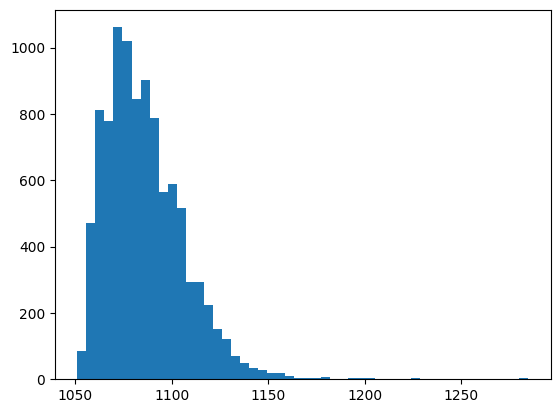

Max prompt length: 1285
Max label length: 3


In [ ]:
# Plot a histogram to find max_length of tokens
utils.find_max_length(mnli_m_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [ ]:
prompt_lengths, _ = utils.get_lengths(mnli_m_val_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 1210 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 1210 tokens and will be truncated: 15 out of 9800 examples or 0.153%


Since we have only 5 examples that goes over a length of 220, we are going to use 220 as the default for `max_length` and miss some information in order to offload computing.

In [ ]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset_few_shot(dataframe=mnli_m_val_few_shot,
                                        examples=prompt_examples,
                                        tokenizer=tokenizer,
                                        dataset_type=global_params['dataset_type'],
                                        prompt_max_length=1210,
                                        label_max_length=3)

batch_size = 16 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [ ]:
# Show an example prompt
print(dataset_test[0]['prompt'])

Examples:
Example 1
Premise: yeah no i don't know if there's any any series that i pay attention to i try to watch Cheers once in a while
Hypothesis: I watch Cheers everynow and then, but I don't watch many series.
Answer: entailment 

Example 2
Premise: my goodness it's hard to believe i didn't think there was anybody in the country who hadn't seen that one
Hypothesis: I thought everyone in the US had already seen that movie. 
Answer: neutral 

Example 3
Premise: As Ben Yagoda writes in the New York Times Book Review , somewhere along the way, Kidder must have decided not to write a book about Tommy O'Connor.
Hypothesis: A book was not written about Tommy O'Connor.
Answer: entailment 

Example 4
Premise: uh-huh well maybe well i've enjoyed talking to you okay bye-bye
Hypothesis: I liked talking to you.
Answer: entailment 

Example 5
Premise: Even if auditors do not follow such other standards and methodologies, they may still serve as a useful source of guidance to auditors in plannin

In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

In [ ]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

No checkpoint found.


Evaluating:   0%|          | 1/613 [00:15<2:38:55, 15.58s/batch]

Checkpoint saved: 1, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_examples.pt


Evaluating:   8%|▊         | 51/613 [12:44<2:20:28, 15.00s/batch]

Checkpoint saved: 51, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_examples.pt


...

Checkpoint saved: 551, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_examples.pt


Evaluating:  98%|█████████▊| 601/613 [2:30:11<02:59, 15.00s/batch]

Checkpoint saved: 601, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_examples.pt


Evaluating: 100%|██████████| 613/613 [2:33:04<00:00, 14.98s/batch]

Checkpoint saved: 613, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_examples.pt


Checkpoint found.
Accuracy: 0.7096.
 Precision: 0.7383.
Recall: 0.7062.
F1 Score: 0.7100.
 Matthew's Correlation Coefficient: 0.5717.
 Cohen's Kappa Score: 0.5639.


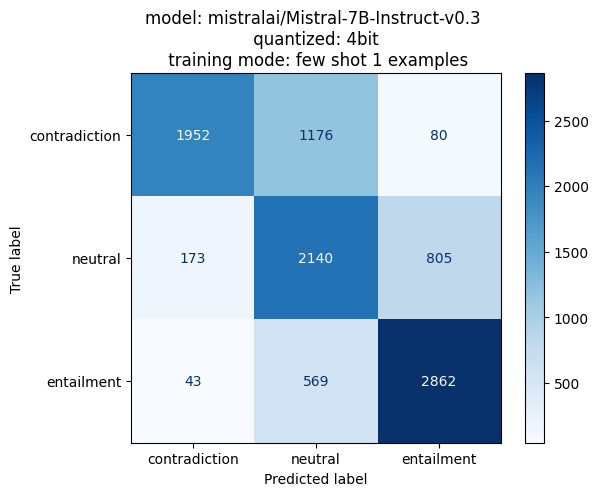

In [ ]:
# Calculate metrics for 1 examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7399.
 Precision: 0.7413.
Recall: 0.7362.
F1 Score: 0.7374.
 Matthew's Correlation Coefficient: 0.6099.
 Cohen's Kappa Score: 0.6089.


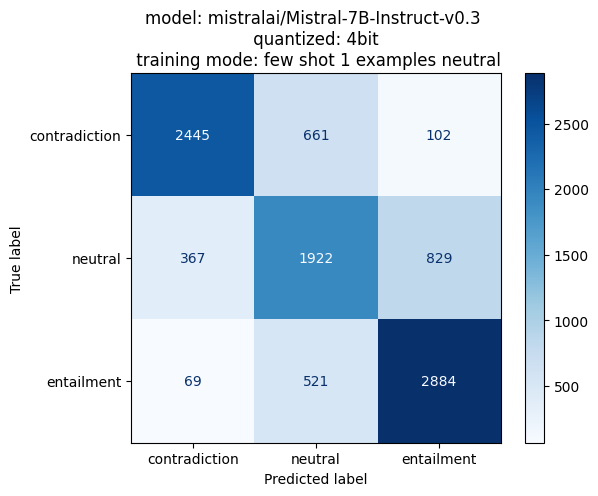

In [ ]:
# Calculate metrics for 1 examples neutral
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7008.
 Precision: 0.7275.
Recall: 0.7011.
F1 Score: 0.7069.
 Matthew's Correlation Coefficient: 0.5582.
 Cohen's Kappa Score: 0.5520.


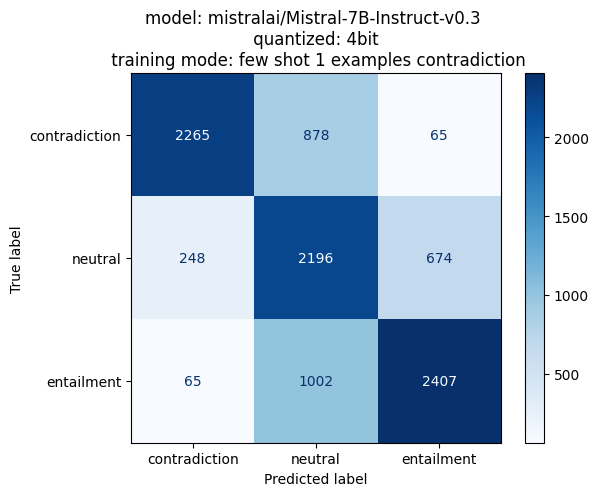

In [ ]:
# Calculate metrics for 1 examples contradiction
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.6683.
 Precision: 0.7127.
Recall: 0.6637.
F1 Score: 0.6661.
 Matthew's Correlation Coefficient: 0.5134.
 Cohen's Kappa Score: 0.5014.


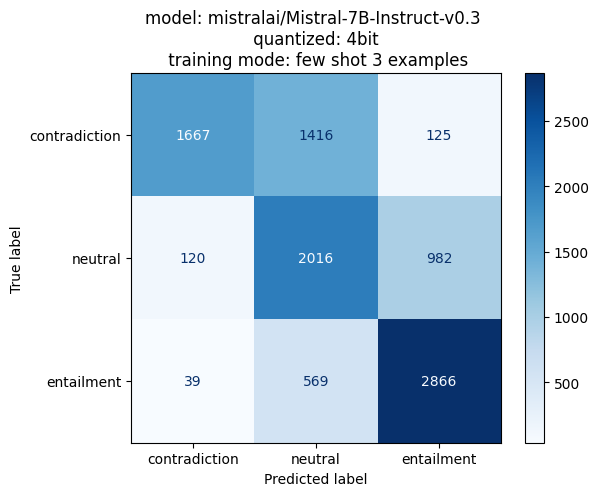

In [ ]:
# Calculate metrics for 3 examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7501.
 Precision: 0.7454.
Recall: 0.7452.
F1 Score: 0.7425.
 Matthew's Correlation Coefficient: 0.6262.
 Cohen's Kappa Score: 0.6237.


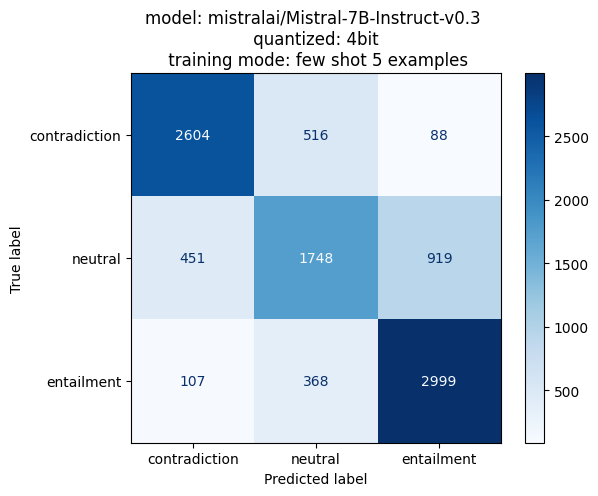

In [ ]:
# Calculate metrics for 5 examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7319.
 Precision: 0.7345.
Recall: 0.7263.
F1 Score: 0.7259.
 Matthew's Correlation Coefficient: 0.6000.
 Cohen's Kappa Score: 0.5961.


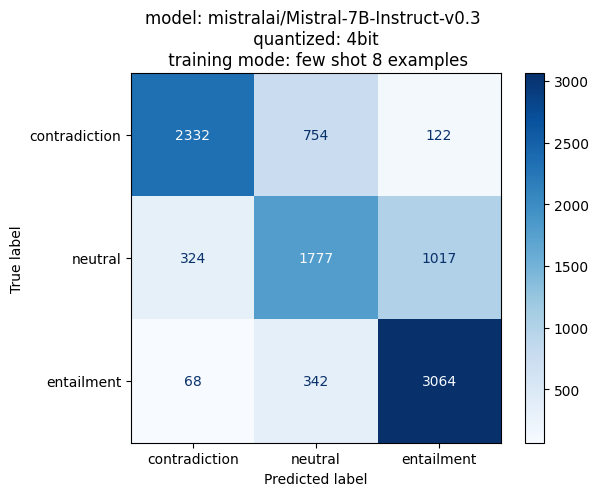

In [ ]:
# Calculate metrics for 8 examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

# <center> Now to test the mismatched validation set separately. <center>

In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'mnli_mm',
                'quantization': '4bit',
                'training_mode': 'few shot 15 mm examples',
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_mm_examples.pt


In [ ]:
# Lock 15 examples to be used for few shot
# files.upload()
mnli_mm_val = pd.read_csv('mnli_mm_val.csv')
mnli_mm_val["label"] = mnli_mm_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_mm_few_shot_example_idx.npy')

k = 15 # Examples to lock
demo_examples = mnli_mm_val.iloc[demo_idxs[:k]]
mnli_mm_val_few_shot = mnli_mm_val.drop(mnli_mm_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Premise: The idiom dressed to the nines could be from Middle English dressed to then eynes `dressed to the eyes.
Hypothesis: The Middle English had a similar idiom.
Answer: entailment 

Example 2
Premise: Make checks payable to Indiana University Foundation.
Hypothesis: If checks are not written to Indiana University Foundation, there will be an issue.
Answer: neutral 

Example 3
Premise: As early as 1 1/2 to 2 years, children begin to talk about the past, guided by adults who prompt them and expand on their fragmented recollections.
Hypothesis: Even when prompted by adults who are guiding them, children will never talk about the past. 
Answer: contradiction 

Example 4
Premise: You got a job cutting siding wasn't it?
Hypothesis: I heard you got a job as a gravedigger.
Answer: contradiction 

Example 5
Premise: In the Roman Catholic Church, for example, women can function as acolytes (one of the minor orders of the diaconate) but may not be officially installed as acolytes.
H

In [ ]:
# Lock 1 opposite examples to be used for few shot
# files.upload()
mnli_mm_val = pd.read_csv('mnli_mm_val.csv')
mnli_mm_val["label"] = mnli_mm_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_mm_few_shot_example_idx.npy')

k = 2 # Examples to lock
demo_examples = mnli_mm_val.iloc[demo_idxs[k]]
mnli_mm_val_few_shot = mnli_mm_val.drop(mnli_mm_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
prompt_examples += f"Example 1\nPremise: {demo_examples['premise']}\nHypothesis: {demo_examples['hypothesis']}\nAnswer: {demo_examples['label']} \n\n"

print(prompt_examples)

Example 1
Premise: As early as 1 1/2 to 2 years, children begin to talk about the past, guided by adults who prompt them and expand on their fragmented recollections.
Hypothesis: Even when prompted by adults who are guiding them, children will never talk about the past. 
Answer: contradiction 




In [ ]:
# Lock 15 examples to be used for few shot
files.upload()

# Load mnli_mm_val
mnli_mm_val = pd.read_csv('mnli_mm_val.csv')
mnli_mm_val["label"] = mnli_mm_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

# Load and get examples from mnli_m_val
demo_idxs = np.load('mnli_m_few_shot_example_idx.npy')
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

k = 1 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[:k]]

# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Saving mnli_m_val.csv to mnli_m_val.csv
Saving mnli_mm_val.csv to mnli_mm_val.csv


Example 1
Premise: yeah no i don't know if there's any any series that i pay attention to i try to watch Cheers once in a while
Hypothesis: I watch Cheers everynow and then, but I don't watch many series.
Answer: entailment 




In [ ]:
# Lock 1 opposite examples to be used for few shot
# files.upload()
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_m_few_shot_example_idx.npy')

k = 5 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[k]]
mnli_m_val_few_shot = mnli_m_val.drop(mnli_m_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
prompt_examples += f"Example 1\nPremise: {demo_examples['premise']}\nHypothesis: {demo_examples['hypothesis']}\nAnswer: {demo_examples['label']} \n\n"

print(prompt_examples)

Example 1
Premise: In addition, Saracens invaded the Provencal coast from North Africa, and Magyar armies attacked Lor?­raine and Bur?­gun?­dy.
Hypothesis: The Magyar armies did not attack anyone.
Answer: contradiction 




In [ ]:
demo_examples

,promptID,pairID,premise,premise_binary_parse,premise_parse,hypothesis,hypothesis_binary_parse,hypothesis_parse,genre,label
9526,19908,19908e,The idiom dressed to the nines could be from M...,( ( ( The idiom ) ( dressed ( to ( the nines )...,(ROOT (S (NP (NP (DT The) (NN idiom)) (VP (VBN...,The Middle English had a similar idiom.,( ( The ( Middle English ) ) ( ( had ( a ( sim...,(ROOT (S (NP (DT The) (NNP Middle) (NNP Englis...,verbatim,entailment
3259,42190,42190n,Make checks payable to Indiana University Foun...,( ( Make ( checks ( payable ( to ( Indiana ( U...,(ROOT (S (VP (VB Make) (S (NP (NNS checks)) (A...,If checks are not written to Indiana Universit...,( ( If ( checks ( ( are not ) ( written ( to (...,(ROOT (S (SBAR (IN If) (S (NP (NNS checks)) (V...,letters,neutral
9615,141150,141150c,"As early as 1 1/2 to 2 years, children begin t...",( ( As ( early ( ( as ( ( 1 1/2 to ) 2 ) ) yea...,(ROOT (S (PP (IN As) (NP (JJ early) (QP (RB as...,Even when prompted by adults who are guiding t...,( ( ( Even when ) ( prompted ( by ( adults ( w...,(ROOT (S (SBAR (WHADVP (RB Even) (WRB when)) (...,oup,contradiction
3880,68549,68549c,You got a job cutting siding wasn't it?,( You ( ( got ( ( a ( job ( cutting siding ) )...,(ROOT (S (NP (PRP You)) (VP (VBD got) (SBAR (S...,I heard you got a job as a gravedigger.,( I ( ( heard ( you ( ( got ( a job ) ) ( as (...,(ROOT (S (NP (PRP I)) (VP (VBD heard) (SBAR (S...,facetoface,contradiction
7347,39449,39449n,"In the Roman Catholic Church, for example, wom...",( ( In ( the ( Roman ( Catholic Church ) ) ) )...,(ROOT (S (PP (IN In) (NP (DT the) (NNP Roman) ...,Roman Catholic Church was praised for their se...,( ( Roman ( Catholic Church ) ) ( ( was ( prai...,(ROOT (S (NP (NNP Roman) (NNP Catholic) (NNP C...,verbatim,neutral
1900,137957,137957e,It suggests that many parents who feel overwhe...,( It ( ( suggests ( that ( ( ( many parents ) ...,(ROOT (S (NP (PRP It)) (VP (VBZ suggests) (SBA...,Many parents who are overwhelmed can free up m...,( ( ( Many parents ) ( who ( are overwhelmed )...,(ROOT (S (NP (NP (JJ Many) (NNS parents)) (SBA...,oup,entailment
7405,72962,72962n,"In Brazil, child street vendors with little or...","( ( In Brazil ) ( , ( ( ( child ( street vendo...","(ROOT (S (PP (IN In) (NP (NNP Brazil))) (, ,) ...",Children who buy and sell goods develop their ...,( ( Children ( who ( ( ( buy and ) sell ) good...,(ROOT (S (NP (NP (NNP Children)) (SBAR (WHNP (...,oup,neutral
3373,55865,55865c,Then watch your gift multiply.,( Then ( ( watch ( your ( gift multiply ) ) ) ...,(ROOT (S (RB Then) (VP (VB watch) (NP (PRP$ yo...,Watch your gift dwindle.,( ( Watch ( your ( gift dwindle ) ) ) . ),(ROOT (S (VP (VB Watch) (NP (PRP$ your) (NN gi...,letters,contradiction


In [ ]:
mnli_mm_val.head()

,promptID,pairID,premise,premise_binary_parse,premise_parse,hypothesis,hypothesis_binary_parse,hypothesis_parse,genre,label
0,75290,75290c,Your contribution helped make it possible for ...,( ( Your contribution ) ( ( helped ( make ( it...,(ROOT (S (NP (PRP$ Your) (NN contribution)) (V...,Your contributions were of no help with our st...,( ( Your contributions ) ( ( were ( of ( ( no ...,(ROOT (S (NP (PRP$ Your) (NNS contributions)) ...,letters,contradiction
1,133794,133794c,"The answer has nothing to do with their cause,...",( ( ( ( ( ( The answer ) ( ( ( ( has nothing )...,(ROOT (S (S (NP (DT The) (NN answer)) (VP (VBZ...,Dictionaries are indeed exercises in bi-unique...,( Dictionaries ( ( ( are indeed ) ( exercises ...,(ROOT (S (NP (NNS Dictionaries)) (VP (VBP are)...,verbatim,contradiction
2,3628,3628c,We serve a classic Tuscan meal that includes ...,( We ( ( serve ( ( a ( classic ( Tuscan meal )...,(ROOT (S (NP (PRP We)) (VP (VBP serve) (NP (NP...,We serve a meal of Florentine terrine.,( We ( ( serve ( ( a meal ) ( of ( Florentine ...,(ROOT (S (NP (PRP We)) (VP (VBP serve) (NP (NP...,verbatim,entailment
3,89411,89411c,"A few months ago, Carl Newton and I wrote a le...","( ( ( A ( few months ) ) ago ) ( , ( ( ( ( Car...",(ROOT (S (ADVP (NP (DT A) (JJ few) (NNS months...,Carl Newton and I have never had any other pre...,( ( ( ( Carl Newton ) and ) I ) ( ( ( have nev...,(ROOT (S (NP (NP (NNP Carl) (NNP Newton)) (CC ...,letters,contradiction
4,136158,136158e,"I was on this earth you know, I've lived on th...",( I ( ( was ( on ( ( this earth ) ( you ( know...,(ROOT (S (NP (PRP I)) (VP (VBD was) (PP (IN on...,I don't yet know the reason why I have lived o...,( I ( ( ( ( do n't ) yet ) ( ( know ( the reas...,(ROOT (S (NP (PRP I)) (VP (VBP do) (RB n't) (A...,facetoface,entailment


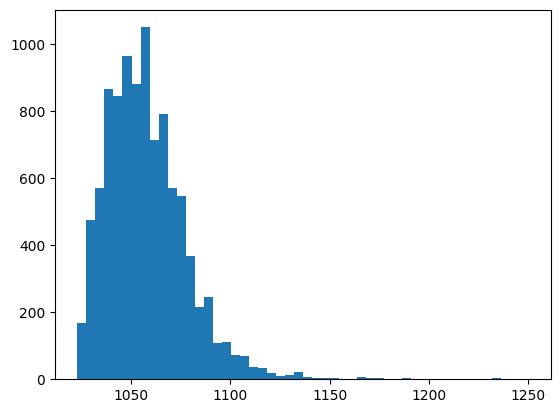

Max prompt length: 1250
Max label length: 3


In [ ]:
# Plot a histogram to find max_length of tokens
utils.find_max_length(mnli_mm_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [ ]:
prompt_lengths, _ = utils.get_lengths(mnli_mm_val_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 1180 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 1180 tokens and will be truncated: 15 out of 9817 examples or 0.153%


In [ ]:
# Define dataset and create a dataloader.
dataset_test_mm = utils.MyDataset_few_shot(dataframe=mnli_mm_val_few_shot,
                                  examples=prompt_examples,
                                    tokenizer=tokenizer,
                                    dataset_type=global_params['dataset_type'],
                                    prompt_max_length=745,
                                    label_max_length=3)

batch_size = 16 # Change batch size according to GPU
dataloader_mm = DataLoader(dataset_test_mm, batch_size=batch_size, shuffle=False)

In [ ]:
# Show an example prompt
print(dataset_test_mm[0]['prompt'])

Examples:
Example 1
Premise: The idiom dressed to the nines could be from Middle English dressed to then eynes `dressed to the eyes.
Hypothesis: The Middle English had a similar idiom.
Answer: entailment 

Example 2
Premise: Make checks payable to Indiana University Foundation.
Hypothesis: If checks are not written to Indiana University Foundation, there will be an issue.
Answer: neutral 

Example 3
Premise: As early as 1 1/2 to 2 years, children begin to talk about the past, guided by adults who prompt them and expand on their fragmented recollections.
Hypothesis: Even when prompted by adults who are guiding them, children will never talk about the past. 
Answer: contradiction 

Example 4
Premise: You got a job cutting siding wasn't it?
Hypothesis: I heard you got a job as a gravedigger.
Answer: contradiction 

Example 5
Premise: In the Roman Catholic Church, for example, women can function as acolytes (one of the minor orders of the diaconate) but may not be officially installed as a

In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader_mm, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader_mm) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

No checkpoint found.


Evaluating:   0%|          | 1/614 [00:08<1:26:00,  8.42s/batch]

Checkpoint saved: 1, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_mm_examples.pt


Evaluating:   8%|▊         | 51/614 [07:15<1:20:19,  8.56s/batch]

Checkpoint saved: 51, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_mm_examples.pt


...

Checkpoint saved: 551, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_mm_examples.pt


Evaluating:  98%|█████████▊| 601/614 [1:25:43<01:51,  8.56s/batch]

Checkpoint saved: 601, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_mm_examples.pt


Evaluating: 100%|██████████| 614/614 [1:27:31<00:00,  8.55s/batch]

Checkpoint saved: 614, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_15_mm_examples.pt


Checkpoint found.
Accuracy: 0.7497.
 F1 Score: 0.7394.
 Matthew's Correlation Coefficient: 0.6265.
 Cohen's Kappa Score: 0.6233.


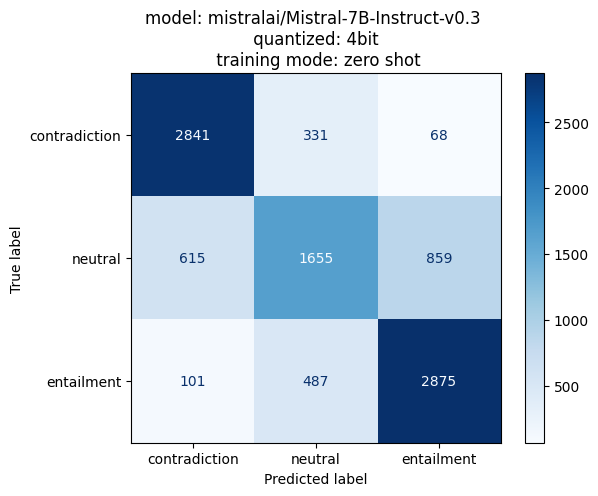

In [ ]:
# Calculate metrics 0 shot
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7193.
 Precision: 0.7467.
Recall: 0.7157.
F1 Score: 0.7197.
 Matthew's Correlation Coefficient: 0.5854.
 Cohen's Kappa Score: 0.5783.


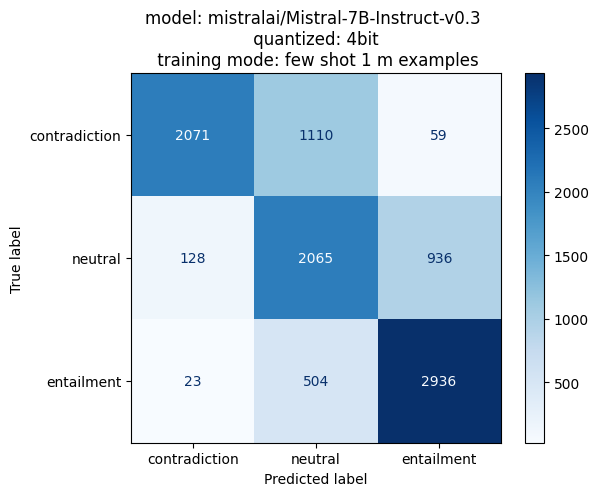

In [ ]:
# Calculate metrics with 1 m examples - 'entailment'
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7419.
 Precision: 0.7451.
Recall: 0.7379.
F1 Score: 0.7390.
 Matthew's Correlation Coefficient: 0.6137.
 Cohen's Kappa Score: 0.6117.


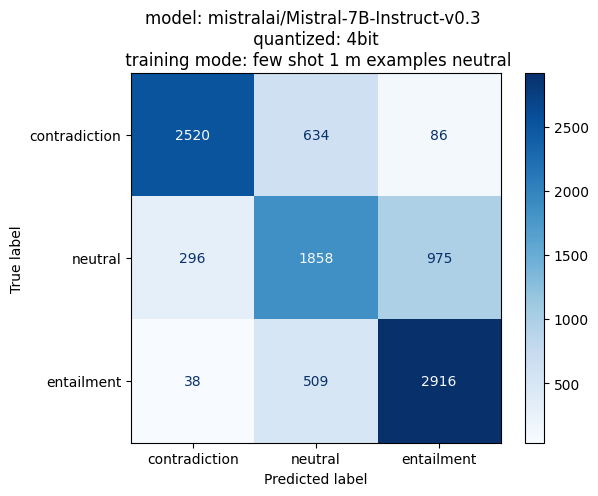

In [ ]:
# Calculate metrics with 1 m examples - 'neutral'
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.6977.
 Precision: 0.7209.
Recall: 0.6970.
F1 Score: 0.7035.
 Matthew's Correlation Coefficient: 0.5510.
 Cohen's Kappa Score: 0.5469.


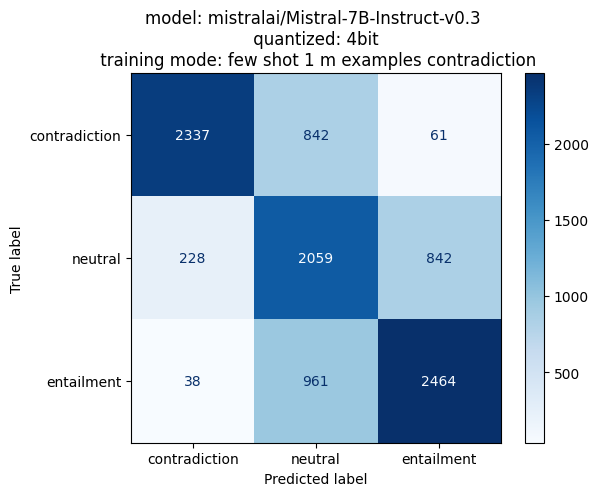

In [ ]:
# Calculate metrics with 1 m examples - 'contradiction'
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7317.
 Precision: 0.7527.
Recall: 0.7296.
F1 Score: 0.7345.
 Matthew's Correlation Coefficient: 0.6021.
 Cohen's Kappa Score: 0.5974.


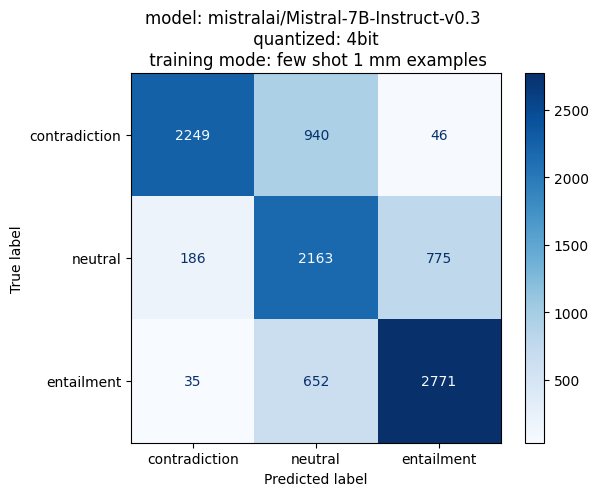

In [ ]:
# Calculate metrics with mm 1 examples - 'entailment'
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7359.
 Precision: 0.7424.
Recall: 0.7360.
F1 Score: 0.7372.
 Matthew's Correlation Coefficient: 0.6061.
 Cohen's Kappa Score: 0.6043.


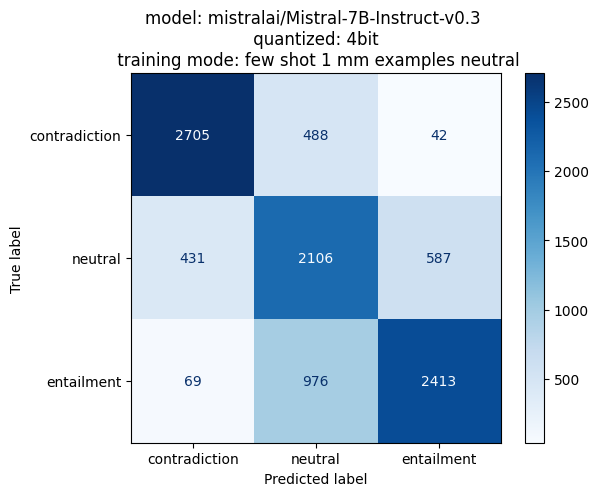

In [ ]:
# Calculate metrics with mm 1 examples - 'neutral'
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7457.
 Precision: 0.7433.
Recall: 0.7433.
F1 Score: 0.7432.
 Matthew's Correlation Coefficient: 0.6182.
 Cohen's Kappa Score: 0.6181.


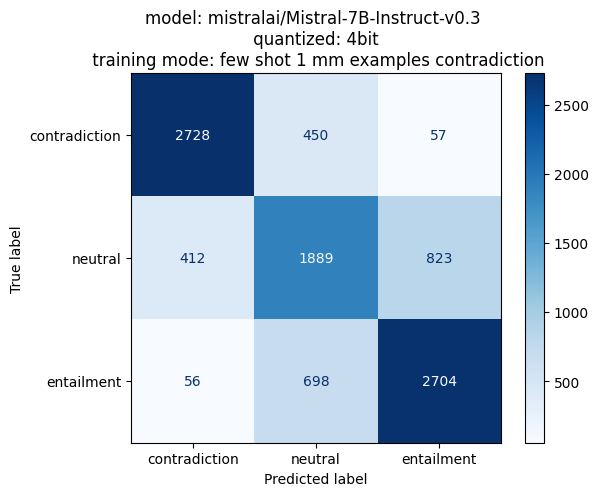

In [ ]:
# Calculate metrics with mm 1 examples - 'contradiction'
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7014.
 Precision: 0.6992.
Recall: 0.6957.
F1 Score: 0.6924.
 Matthew's Correlation Coefficient: 0.5546.
 Cohen's Kappa Score: 0.5500.


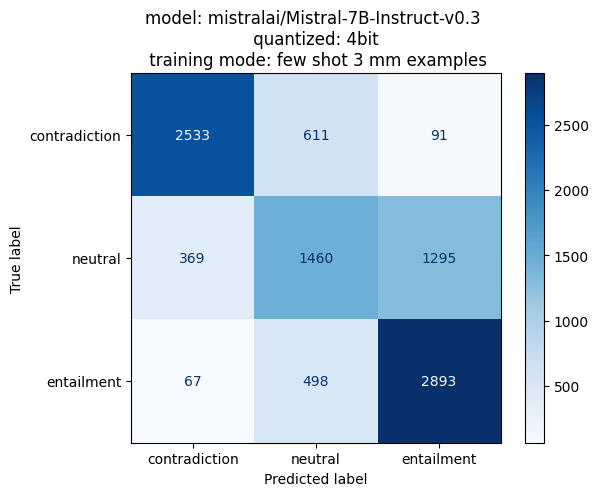

In [ ]:
# Calculate metrics with 3 mm examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.6801.
 Precision: 0.6829.
Recall: 0.6703.
F1 Score: 0.6524.
 Matthew's Correlation Coefficient: 0.5388.
 Cohen's Kappa Score: 0.5156.


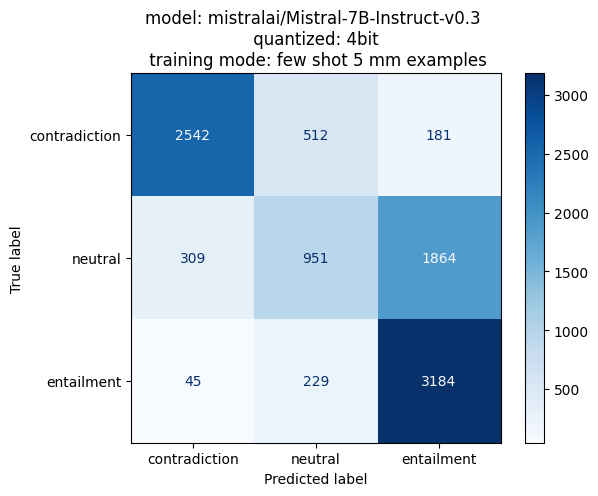

In [ ]:
# Calculate metrics with 5 mm examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7090.
 Precision: 0.7080.
Recall: 0.7010.
F1 Score: 0.6897.
 Matthew's Correlation Coefficient: 0.5739.
 Cohen's Kappa Score: 0.5602.


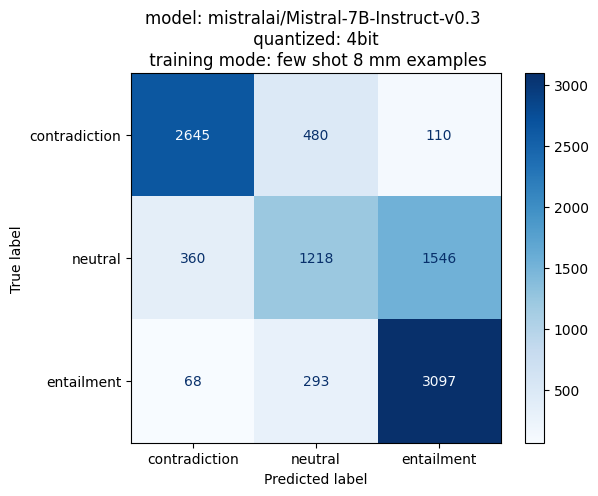

In [ ]:
# Calculate metrics with 8 mm examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.6863.
 Precision: 0.6883.
Recall: 0.6781.
F1 Score: 0.6664.
 Matthew's Correlation Coefficient: 0.5407.
 Cohen's Kappa Score: 0.5257.


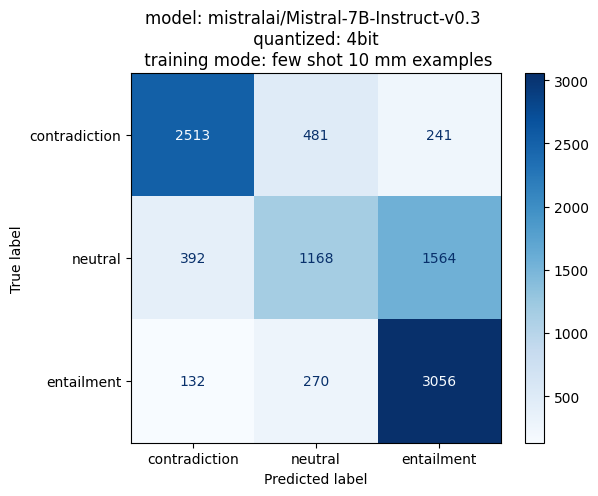

In [ ]:
# Calculate metrics with 10 mm examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.3182.
 Precision: 0.1061.
Recall: 0.3333.
F1 Score: 0.1609.
 Matthew's Correlation Coefficient: 0.0000.
 Cohen's Kappa Score: 0.0000.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


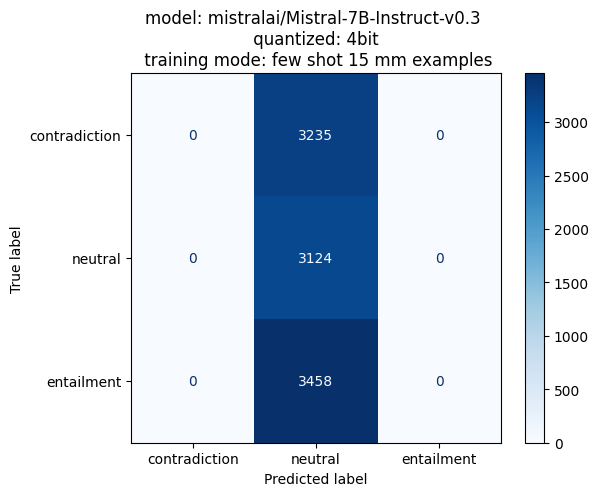

In [ ]:
# Calculate metrics with 15 mm examples
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)